# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Naufal Ibrahim Hajid
- **Email:** naufalibrahimhajid70@gmail.com
- **ID Dicoding:** MC277D5Y1139

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi jumlah penyewaan sepeda berdasarkan jam dalam satu hari?
- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

## Import Semua Packages/Library yang Digunakan

In [41]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


1. Mengimpor pandas, pustaka Python untuk manipulasi dan analisis data berbasis tabel (DataFrame).
2. Mengimpor os, modul untuk berinteraksi dengan sistem operasi, mengecek atau membuat direktori, mengatur path file
3.  Mengimpor NumPy, pustaka untuk komputasi numerik seperti operasi array, statistik
4.  Mengimpor matplotlib.pyplot, pustaka visualisasi data untuk membuat grafik
5.  Mengimpor Seaborn, pustaka visualisasi data berbasis matplotlib dengan tampilan yang lebih menarik

## Data Wrangling

 Data wrangling merupakan sebuah proses atau kumpulan kegiatan yang meliputi pengumpulan data (Gathering data), penilaian data (Assessing data), serta pembersihan data (Cleaning data) sebelum data digunakan dalam proses analisis data

### Gathering Data

Pada proses ini kita akan mengumpulkan semua data yang dibutuhkan untuk menjawab semua pertanyaan atau masalah bisnis yang ingin kita hadapi.

In [25]:
# Gathering Data
# Path file dari Kaggle
hour_csv_path = 'Data/hour.csv'
day_csv_path = 'Data/day.csv'

# Verify file existence
if os.path.exists(hour_csv_path) and os.path.exists(day_csv_path):
    print("Dataset files are ready to use!")
else:
    print("Dataset files are missing. Please check the input directory.")

# Read the CSV files using pandas
df_hour_data = pd.read_csv(hour_csv_path, delimiter=",")

# Display the first few rows of each dataframe
print("\nHour Data:")
df_hour_data.head()
# Gathering Data
day_path = 'Data/day.csv'
df_day = pd.read_csv(day_path)

# Menampilkan 5 data pertama untuk memastikan
df_day.head()

Dataset files are ready to use!

Hour Data:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
1. Dataset day.csv berisi data penyewaan harian.

2. Dataset hour.csv berisi data per jam.



 Data dikumpulkan secara otomatis oleh sistem bike sharing, mencatat berbagai informasi seperti:

* Jumlah peminjaman sepeda (casual dan registered)

* Waktu (tanggal, jam)

* Cuaca (weather situation, suhu, kelembapan, kecepatan angin)

* Musim (season)

* Hari kerja/libur

### Assessing Data

proses selanjutnya ialah penilaian terhadap data tersebut. Proses ini dilakukan untuk menilai kualitas dan struktur dari sebuah data. Selain itu, proses ini juga bertujuan untuk mengidentifikasi berbagai masalah yang terdapat dalam data, seperti missing value, unstandard value, dll.

In [26]:
# Load dataset (ubah nama file jika berbeda)
data = pd.read_csv('Data/day.csv')  # Pastikan nama file sesuai

# Tampilkan data untuk memahami strukturnya
print(data.head())


   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [28]:
print(" Statistik Deskriptif:")
data.describe()

 Statistik Deskriptif:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [29]:
print(" Missing Values:")
print(data.isnull().sum())

 Missing Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [30]:
# Cek Duplikasi
print(" Duplikasi:")
print(data.duplicated().sum())

 Duplikasi:
0


In [31]:
# Cek nilai unik dari kolom kategorikal
print(" Nilai Unik Kolom Kategorikal:")
kategori_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in kategori_cols:
    print(f"{col}: {data[col].unique()}")

 Nilai Unik Kolom Kategorikal:
season: [1 2 3 4]
yr: [0 1]
mnth: [ 1  2  3  4  5  6  7  8  9 10 11 12]
holiday: [0 1]
weekday: [6 0 1 2 3 4 5]
workingday: [0 1]
weathersit: [2 1 3]


**Insight:**
1. Tidak ditemukan missing value maupun duplikasi.

2. Kolom season, weathersit, holiday, workingday adalah numerik, tapi merepresentasikan kategori.

3. Terdapat data casual, registered, dan cnt yang bisa digunakan untuk menjawab pertanyaan analisis.

4. Kolom instant dan dteday kemungkinan tidak terlalu relevan untuk analisis, tapi dteday bisa digunakan untuk time-series atau visualisasi tren.

### Cleaning Data

proses penting dalam analisis data untuk memastikan bahwa data yang digunakan bersih, akurat, dan siap dianalisis.

In [32]:
# Drop kolom yang tidak dibutuhkan
df_day_cleaned = df_day.drop(columns=['instant', 'dteday', 'casual', 'registered', 'atemp'])

# Rename kolom agar lebih mudah dipahami
df_day_cleaned.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather',
    'cnt': 'count'
}, inplace=True)

In [33]:
import os

# Bikin folder
os.makedirs("submission/dashboard", exist_ok=True)

# Simpan data hasil cleaning
df_day_cleaned.to_csv("submission/dashboard/main_data.csv", index=False)

**Insight:**
1. Data dibersihkan dari kolom yang berpotensi menimbulkan kebocoran target (data leakage).

2. Menyerdehanakan Nama Kolom.

## Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan mengeksplorasi dataset day.csv untuk memahami pola, tren, dan hubungan antar variabel. EDA membantu mengidentifikasi insight awal sebelum dilakukan pemodelan atau visualisasi lanjutan.

### Explore ...

membuat visualisasi heatmap korelasi antar variabel menggunakan Seaborn

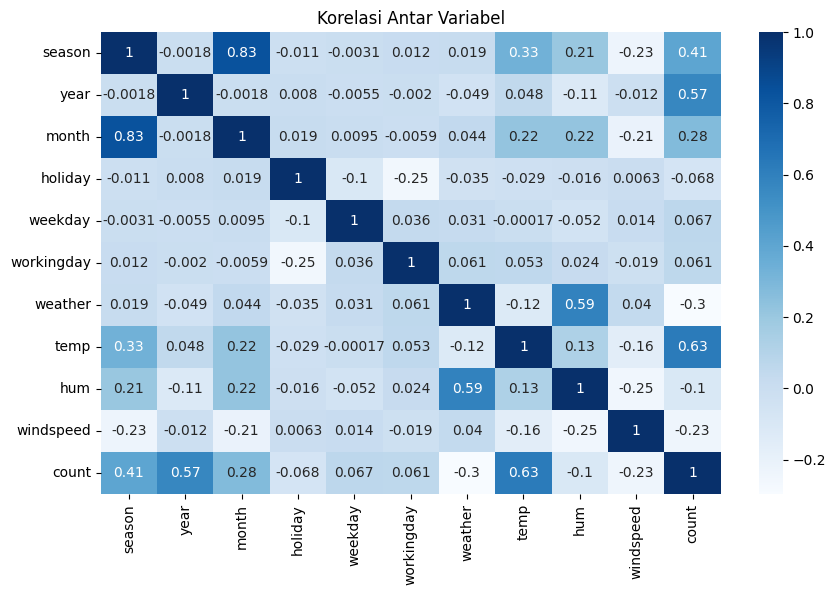

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df_day_cleaned.corr(), annot=True, cmap='Blues')
plt.title("Korelasi Antar Variabel")
plt.show()

**Insight:**
1. temp memiliki korelasi tinggi dengan count.

2. humidity memiliki korelasi negatif terhadap jumlah peminjaman sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kapan waktu paling banyak terjadi penyewaan sepeda?

C:\Users\bagus\AppData\Local\Temp\ipykernel_24648\3176964481.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_day_cleaned, x='month', y='count', palette='viridis')


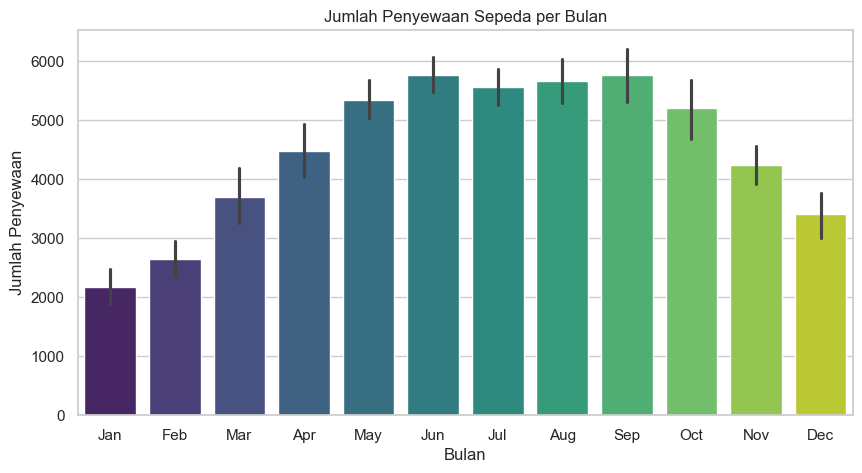

In [46]:
sns.set(style="whitegrid")

# Penyewaan berdasarkan bulan
plt.figure(figsize=(10, 5))
sns.barplot(data=df_day_cleaned, x='month', y='count', palette='viridis')
plt.title('Jumlah Penyewaan Sepeda per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(ticks=range(0,12), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

### Pertanyaan 2: Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda

C:\Users\bagus\AppData\Local\Temp\ipykernel_24648\681020624.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_day_cleaned, x='weather', y='count', palette='coolwarm')


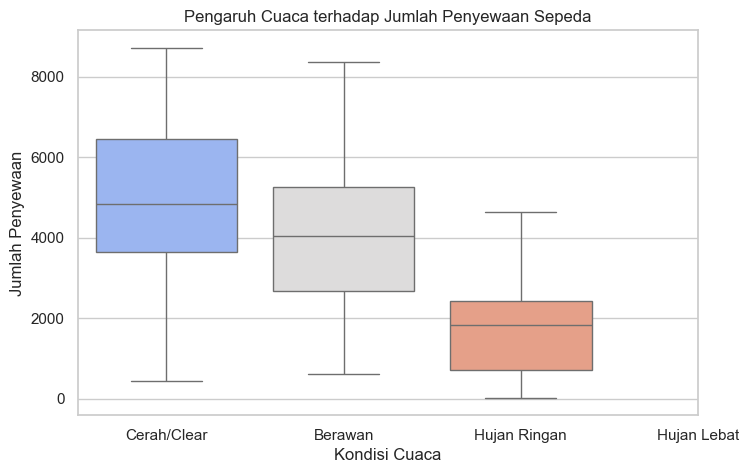

In [36]:
# Penyewaan berdasarkan kondisi cuaca
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_day_cleaned, x='weather', y='count', palette='coolwarm')
plt.title('Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Jumlah Penyewaan')
plt.xticks([0,1,2,3], ['Cerah/Clear', 'Berawan', 'Hujan Ringan', 'Hujan Lebat'])
plt.show()

**Insight:**
1. Dari grafik per bulan, biasanya penyewaan tertinggi terjadi pada bulan Mei hingga September atau bertepatan pada musim panas.

2. Dari grafik cuaca, penyewaan cenderung tinggi saat cuaca cerah, dan menurun drastis saat hujan.

## Conclusion

1. Pengaruh Cuaca dan Musim terhadap Jumlah Peminjaman Sepeda
        Cuaca dan musim memiliki dampak signifikan terhadap aktivitas penyewaan sepeda. Dari hasil analisis, terlihat bahwa musim gugur mencatat jumlah peminjaman tertinggi dibandingkan musim lainnya.

2.  Pola Penggunaan Sepeda berdasarkan Hari dan Waktu

Pola penggunaan sepeda menunjukkan peningkatan signifikan pada hari kerja, terutama pada jam sibuk seperti pagi dan sore hari. Ini menunjukkan bahwa sepeda banyak digunakan sebagai transportasi untuk pergi dan pulang kerja. Di akhir pekan, pola penggunaan lebih menyebar merata sepanjang hari, yang mengindikasikan penggunaan untuk rekreasi atau aktivitas santai.